<a href="https://colab.research.google.com/github/abhigyan369/ml-lab/blob/main/feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Handing Missing Data

In [1]:
import seaborn as sns

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
## checki missing values
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [4]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [6]:
## delete the rows or data point to handle missing data
df.shape

(891, 15)

In [ ]:
## df.dropna().shape

In [7]:
## column wise deletion
df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


# Imputation Missing Value Techniques
### 1. Mean Value Imputation

<Axes: xlabel='age', ylabel='Count'>

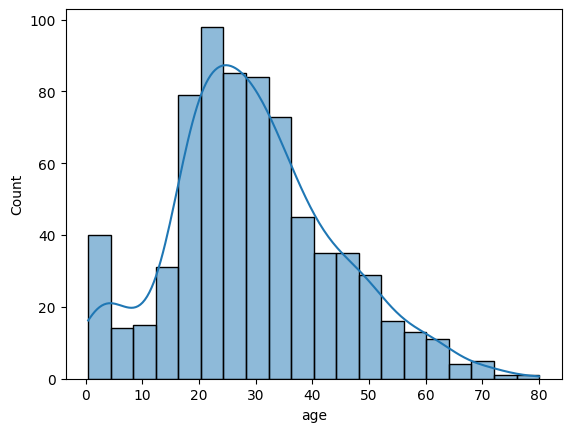

In [9]:
sns.histplot(df['age'], kde=True)

In [13]:
df['age_mean'] = df['age'].fillna(df['age'].mean())

In [14]:
df[['age_mean', 'age']]

,age_mean,age
0,22.000000,22.000000
1,38.000000,38.000000
2,26.000000,26.000000
3,35.000000,35.000000
4,35.000000,35.000000
...,...,...
886,27.000000,27.000000
887,19.000000,19.000000
888,29.699118,29.699118
889,26.000000,26.000000


In [ ]:
## mean imputation works well when we have normally distributed data

### 2. Median Value Imputation- if we have outliers

In [15]:
df['age_median'] = df['age'].fillna(df['age'].median())

In [16]:
df[['age_median', 'age']]

,age_median,age
0,22.000000,22.000000
1,38.000000,38.000000
2,26.000000,26.000000
3,35.000000,35.000000
4,35.000000,35.000000
...,...,...
886,27.000000,27.000000
887,19.000000,19.000000
888,29.699118,29.699118
889,26.000000,26.000000


### 3. Mode Imputation - categorical Values


In [24]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_median,age_mean,mode_age


In [22]:
df['embarked']

,embarked
0,S
1,C
2,S
3,S
4,S
...,...
886,S
887,S
888,S
889,C


In [26]:
df['embarked'].unique()

array(['S', 'C', 'Q', np.float64(29.69911764705882)], dtype=object)

In [ ]:
df['new_embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Handling Imbalanced Dataset
### 1. Up sampling
### 2. Down sampling

In [27]:
import numpy as np
import pandas as pd
np.random.seed(123)
n_samples = 1000
class_0_ratio =0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [28]:
n_class_0, n_class_1

(900, 100)

In [29]:
## CREATE MY DATAFRAME WITH IMBALANCED DATASET
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

In [30]:
df=pd.concat([class_0,class_1]).reset_index(drop=True)

In [31]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [34]:
df['target'].value_counts()

,count
target,
0,900
1,100


In [35]:
## upsampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [36]:
from sklearn.utils import resample
df_minority_upsampled=resample(df_minority,replace=True, #Sample With replacement
         n_samples=len(df_majority),
         random_state=42
        )

In [37]:
df_minority_upsampled.shape

(900, 3)

In [38]:
df_minority_upsampled.head()

,feature_1,feature_2,target
951,1.125854,1.843917,1
992,2.196570,1.397425,1
914,1.932170,2.998053,1
971,2.272825,3.034197,1
960,2.870056,1.550485,1


In [39]:
df_upsampled=pd.concat([df_majority,df_minority_upsampled])

In [40]:
df_upsampled['target'].value_counts()

,count
target,
0,900
1,900


## Down Sampling

In [41]:
import pandas as pd

# Set the random seed for reproducibility
np.random.seed(123)

# Create a dataframe with two classes
n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0, scale=1, size=n_class_0),
    'feature_2': np.random.normal(loc=0, scale=1, size=n_class_0),
    'target': [0] * n_class_0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=2, scale=1, size=n_class_1),
    'feature_2': np.random.normal(loc=2, scale=1, size=n_class_1),
    'target': [1] * n_class_1
})

df = pd.concat([class_0, class_1]).reset_index(drop=True)

# Check the class distribution
print(df['target'].value_counts())

target
0    900
1    100
Name: count, dtype: int64


In [42]:
## downsampling
df_minority=df[df['target']==1]
df_majority=df[df['target']==0]

In [43]:
from sklearn.utils import resample
df_majority_upsampled=resample(df_minority,replace=True, #Sample With replacement
         n_samples=len(df_majority),
         random_state=42
        )

## Data Encoding

1. Nominal/OHE Encoding
2. Label and Ordinal Encoding
3. Target Guided Ordinal Encoding

### Nominal/OHE Encoding
One hot encoding, also known as nominal encoding, is a technique used to represent categorical data as numerical data, which is more suitable for machine learning algorithms. In this technique, each category is represented as a binary vector where each bit corresponds to a unique category. For example, if we have a categorical variable "color" with three possible values (red, green, blue), we can represent it using one hot encoding as follows:

1. Red: [1, 0, 0]
2. Green: [0, 1, 0]
3. Blue: [0, 0, 1]

In [44]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [45]:
## create a dataframe
df = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'green', 'red', 'blue']
})

In [46]:
df.head()

,color
0,red
1,blue
2,green
3,green
4,red


In [47]:
##create an instance of Onehotencoder
encoder=OneHotEncoder()

In [48]:
## perform fit and transform
encoded=encoder.fit_transform(df[['color']]).toarray()

In [49]:
encoder_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [50]:
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


In [51]:
## for new data
encoder.transform([['blue']]).toarray()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0.]])

In [52]:
pd.concat([df,encoder_df],axis=1)

,color,color_blue,color_green,color_red
0,red,0.0,0.0,1.0
1,blue,1.0,0.0,0.0
2,green,0.0,1.0,0.0
3,green,0.0,1.0,0.0
4,red,0.0,0.0,1.0
5,blue,1.0,0.0,0.0


### Label Encoding
Label encoding and ordinal encoding are two techniques used to encode categorical data as numerical data.

Label encoding involves assigning a unique numerical label to each category in the variable. The labels are usually assigned in alphabetical order or based on the frequency of the categories. For example, if we have a categorical variable "color" with three possible values (red, green, blue), we can represent it using label encoding as follows:

1. Red: 1
2. Green: 2
3. Blue: 3

In [53]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()

In [54]:
lbl_encoder.fit_transform(df[['color']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 1, 2, 0])

In [55]:
lbl_encoder.transform([['red']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

In [56]:
lbl_encoder.transform([['blue']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0])

### Ordinal Encoding
It is used to encode categorical data that have an intrinsic order or ranking. In this technique, each category is assigned a numerical value based on its position in the order. For example, if we have a categorical variable "education level" with four possible values (high school, college, graduate, post-graduate), we can represent it using ordinal encoding as follows:

1. High school: 1
2. College: 2
3. Graduate: 3
4. Post-graduate: 4

In [57]:
from sklearn.preprocessing import OrdinalEncoder

In [58]:
# create a sample dataframe with an ordinal variable
df = pd.DataFrame({
    'size': ['small', 'medium', 'large', 'medium', 'small', 'large']
})

In [59]:
df

,size
0,small
1,medium
2,large
3,medium
4,small
5,large


In [60]:
## create an instance of ORdinalEncoder and then fit_transform
encoder=OrdinalEncoder(categories=[['small','medium','large']])

In [61]:
encoder.fit_transform(df[['size']])

array([[0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [2.]])